## Predicting Heart Diseases: 

### Steps to Follow: 
1) Load Data
2) Check Data Quality
3) Clean Data
    1) Check for missing Data 
    2) Review Data Distribution for Each Feature
4) Check Data Distribution for Target
5) Stratified K-Folds for Model Comparison
6) Choose Best Performing Model using AUC Score or F1 Score.
7) HyperParameter Tuning
8) Look at Feature Importance
9) Get Predictions and Store in "submission.csv"

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report, f1_score

from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
import catboost as ctb

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna

from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

sns.set_theme()

## Load Data

In [2]:
class Config:
    train_path = "/kaggle/input/playground-series-s6e2/train.csv"
    test_path = "/kaggle/input/playground-series-s6e2/test.csv"

In [3]:
train_data = pd.read_csv(Config.train_path)
test_data = pd.read_csv(Config.test_path)

train_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
print("Total Train Samples:", len(train_data))
print("Total Test Samples:", len(test_data))

Total Train Samples: 630000
Total Test Samples: 270000


## Check Data Quality

In [5]:
# Check for Missing Data
print("Null Counts for Each Column:\n")
display(train_data.isna().sum())

print("Data Type for Each Column:\n")
display(train_data.info())

Null Counts for Each Column:



id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Data Type for Each Column:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000

None

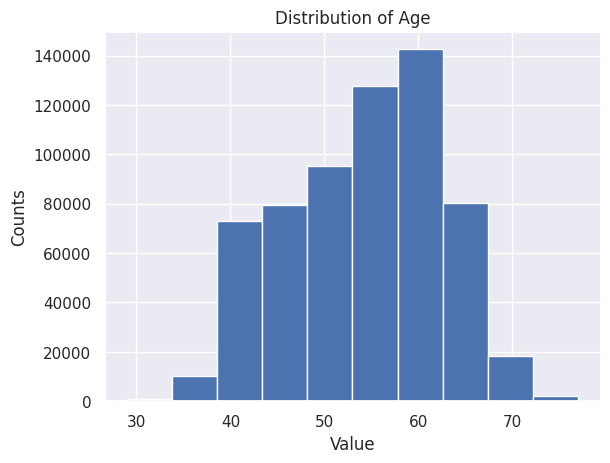

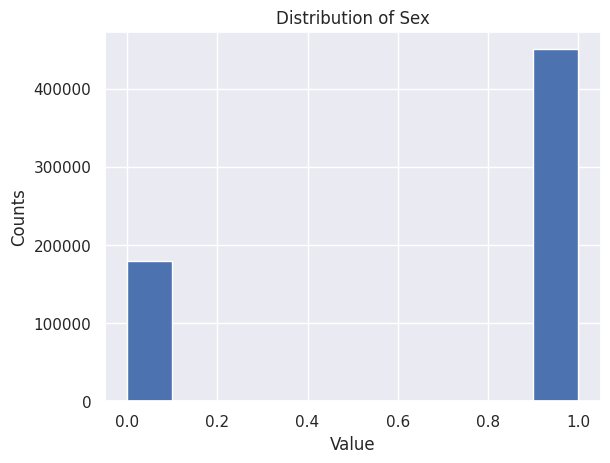

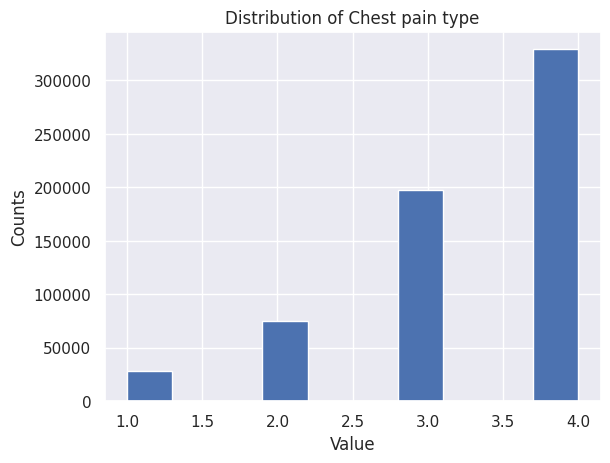

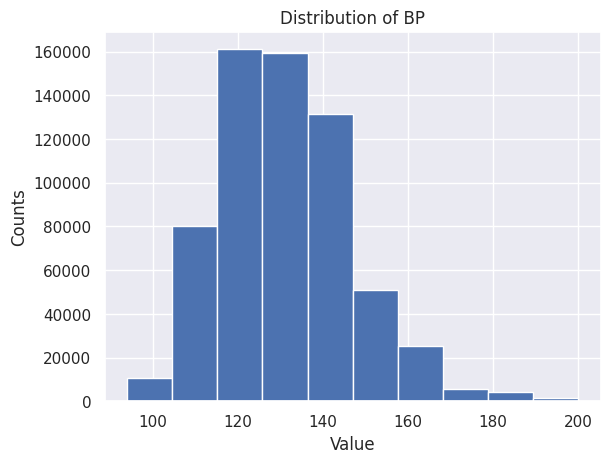

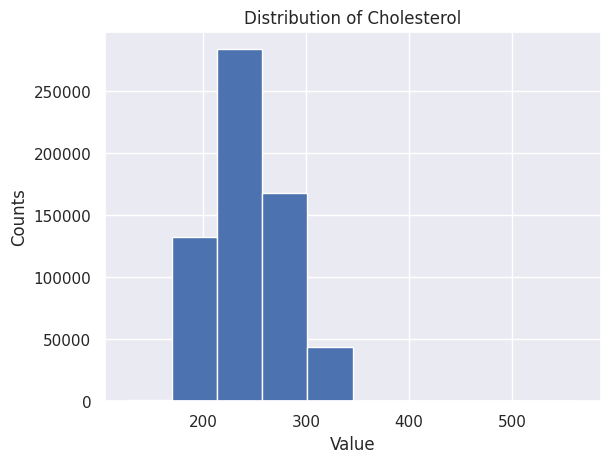

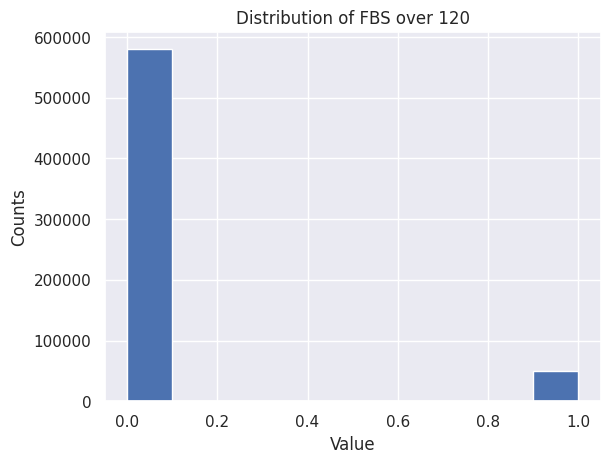

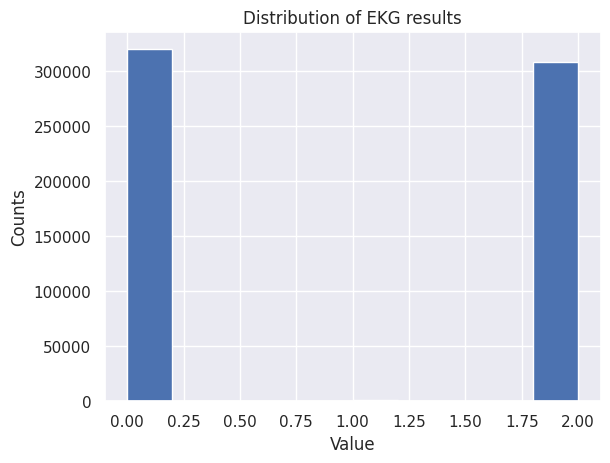

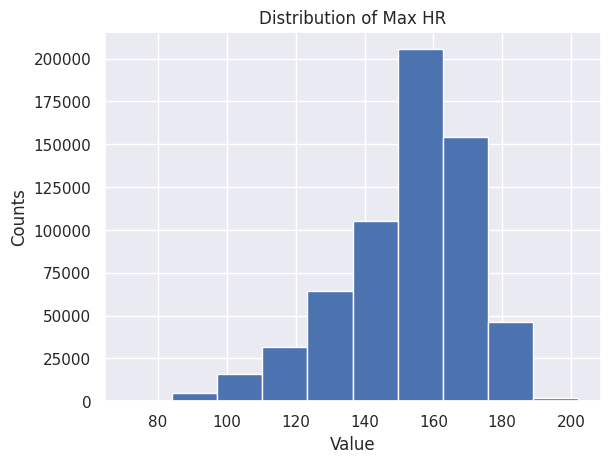

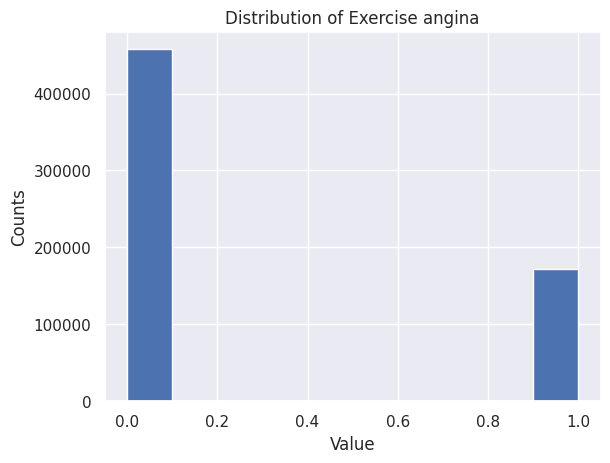

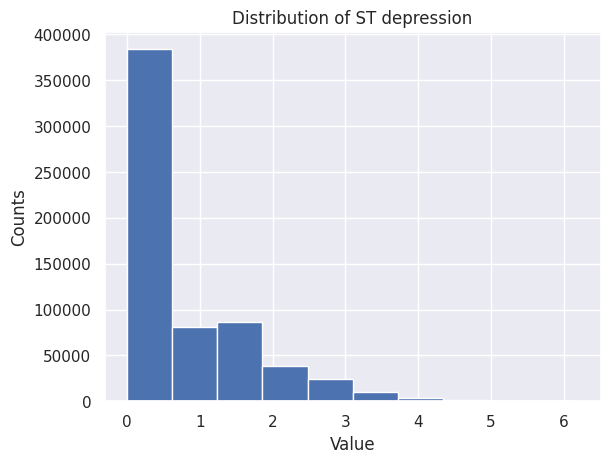

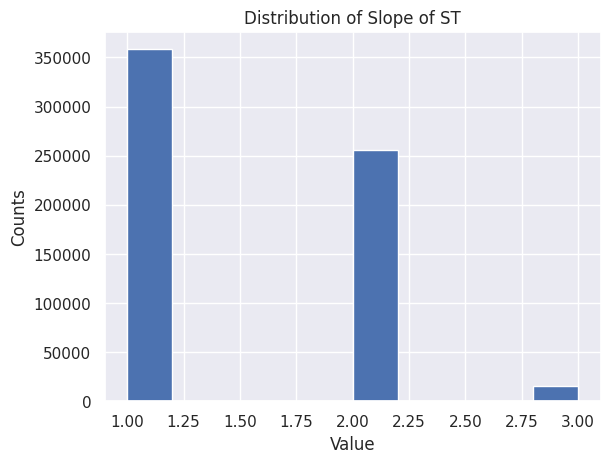

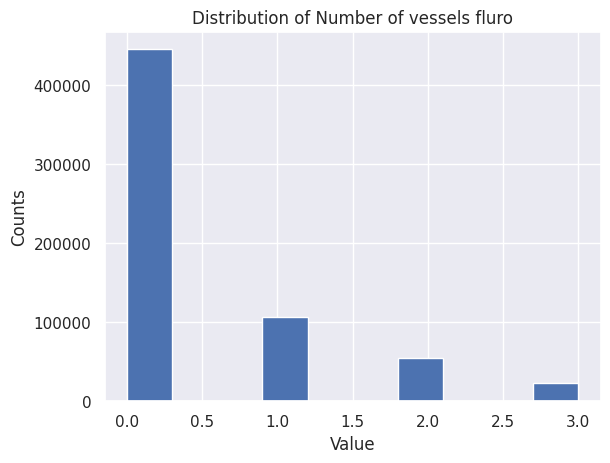

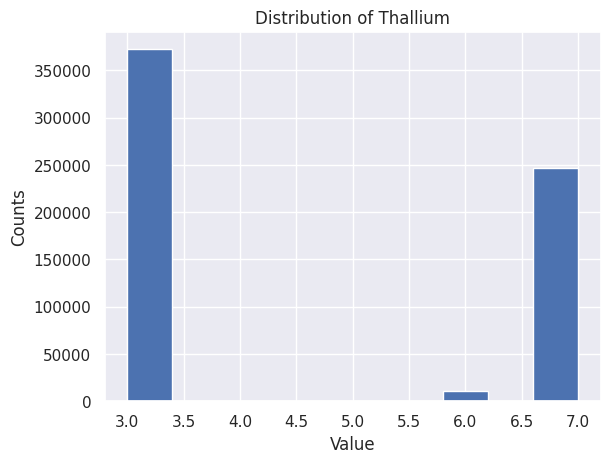

In [6]:
# Plot Distribution for Each Feature Column
target = "Heart Disease"
features = [i for i in train_data.columns[1:] if i!=target]

for i in features:
    train_data[i].hist()
    plt.title(f"Distribution of {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.show()

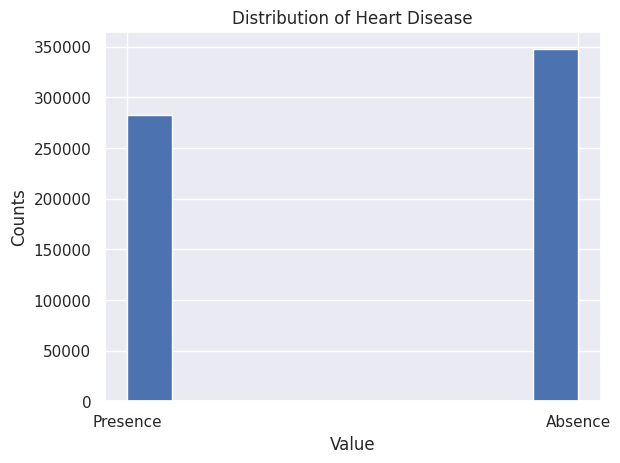

In [7]:
# Plot Distribution for Each Target Column
train_data[target].hist()
plt.title(f"Distribution of {target}")
plt.xlabel("Value")
plt.ylabel("Counts")
plt.show()

## Stratified K-Folds for Model Comparison

In [8]:
def evaluate_model(ModelClass, X, y, splits=4, verbose=False, **kwargs):
    skf = StratifiedKFold(n_splits=splits)
    f1_scores = []
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        if verbose:
            print(f"Fold {i}:")
            print("Train Samples:", len(train_index))
            print("Test Samples:", len(test_index))
            
        scaler = StandardScaler().set_output(transform="pandas")
        X_train = scaler.fit_transform(train_data.loc[train_index, features])
        y_train = y[train_index]
        X_test = scaler.transform(train_data.loc[test_index, features])
        y_test = y[test_index]
        
        model = ModelClass(**kwargs)
    
        model.fit(X_train, y_train)
    
        y_prob = model.predict(X_test)
        
        score = f1_score(y_test, y_prob)
        report = classification_report(y_test, y_prob, target_names=label_encoder.classes_)

        f1_scores.append(score)
        
        if verbose: 
            print("F1-Score:", f1_score)
            print(report)
    
    return np.mean(f1_scores), np.std(f1_scores)

In [9]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_data[target])

print('Total Classes:', len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)
exps = [
    {"ModelClass": LogisticRegression, "X": train_data, "y": y, "class_weight":"balanced"}, 
    {"ModelClass": GaussianNB, "X": train_data, "y": y},
    # {"ModelClass": RandomForestClassifier, "X": train_data, "y": y, "class_weight":"balanced"},
    # {"ModelClass": DecisionTreeClassifier, "X": train_data, "y": y, "class_weight":"balanced"},
    # {"ModelClass": SVC, "X": train_data, "y": y, "class_weight":"balanced"},
    # {"ModelClass": KNeighborsClassifier, "X": train_data, "y": y},
    # {"ModelClass": GradientBoostingClassifier, "X": train_data, "y": y},
    {"ModelClass": ctb.CatBoostClassifier, "X": train_data, "y": y, "verbose": False, "logging_level":"Silent"},
    {"ModelClass": lgb.LGBMClassifier, "X": train_data, "y": y, "class_weight":"balanced", "verbosity": 0}, 
    {"ModelClass": xgb.XGBClassifier, "X": train_data, "y": y, "class_weight":"balanced", "verbosity": 0},
]

for param in exps: 
    mean, std = evaluate_model(**param)
    print(f"Model: {param['ModelClass'].__name__}\nMean: {mean} | STD: {std}")

Total Classes: 2
Classes: ['Absence' 'Presence']
Model: LogisticRegression
Mean: 0.8698156930064391 | STD: 0.00031922046671325387
Model: GaussianNB
Mean: 0.8559808287704908 | STD: 0.00046478771664728365
Model: CatBoostClassifier
Mean: 0.8745092146055211 | STD: 0.00041284972618127794
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Model: LGBMClassifier
Mean: 0.8752286835444213 | STD: 0.0003561966268476274
Model: XGBClassifier
Mean: 0.8739894614488471 | STD: 0.00047275632674916685


## HyperParameter Tuning

In [10]:
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "n_jobs": -1,
        "class_weight": "balanced",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 512),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 75, 125),
    }

    f1_scores = []

    for train_idx, val_idx in skf.split(train_data[features], y):
        X_train_fold, X_val_fold = train_data[features].iloc[train_idx], train_data[features].iloc[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        scaler = StandardScaler().set_output(transform="pandas")
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        preds = model.predict(X_val_fold)
        f1 = f1_score(y_val_fold, preds)
        f1_scores.append(f1)

        trial.report(np.mean(f1_scores), step=len(f1_scores))
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(f1_scores)

In [11]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials=100)

print("Best F1:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-02-12 16:52:41,258] A new study created in memory with name: no-name-b15a2536-1fad-4baa-8332-079f31706110
[I 2026-02-12 16:53:18,154] Trial 0 finished with value: 0.8737673150482486 and parameters: {'learning_rate': 0.005611516415334507, 'num_leaves': 488, 'max_depth': 12, 'min_child_samples': 62, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'n_estimators': 105}. Best is trial 0 with value: 0.8737673150482486.
[I 2026-02-12 16:53:38,425] Trial 1 finished with value: 0.8725013807478139 and parameters: {'learning_rate': 0.02607024758370768, 'num_leaves': 26, 'max_depth': 15, 'min_child_samples': 84, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'n_estimators': 101}. Best is trial 0 with value: 0.8737673150482486.
[I 2026-02-12 16:54:02,846] Trial 2 finished with value: 0.872792196775

Best F1: 0.8755488861676024
Best Params: {'learning_rate': 0.061946832135484124, 'num_leaves': 325, 'max_depth': 9, 'min_child_samples': 63, 'subsample': 0.5666465147651386, 'colsample_bytree': 0.5510804572938013, 'reg_alpha': 2.6537797657554993e-08, 'reg_lambda': 8.027611180978036e-07, 'n_estimators': 119}


## Retrain Best Model with Best HyperParameters

In [12]:
X_train, X_test, y_train, y_test = train_test_split(train_data[features], y, test_size=0.1, random_state=42, stratify=y)

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = lgb.LGBMClassifier(class_weight="balanced", verbosity=0, **study.best_params)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

LGBMClassifier(class_weight='balanced', colsample_bytree=0.5510804572938013,
               learning_rate=0.061946832135484124, max_depth=9,
               min_child_samples=63, n_estimators=119, num_leaves=325,
               reg_alpha=2.6537797657554993e-08,
               reg_lambda=8.027611180978036e-07, subsample=0.5666465147651386,
               verbosity=0)

In [13]:
f1_score(y_test, model.predict(X_test))

0.8780616276007375

## Evaluate Feature Importance

In [14]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
                    Feature  Importance Mean  Importance Std
12                 Thallium         0.046117        0.000951
7                    Max HR         0.037128        0.000883
2           Chest pain type         0.032033        0.000941
11  Number of vessels fluro         0.018869        0.000502
8           Exercise angina         0.011709        0.000568
9             ST depression         0.009179        0.000536
10              Slope of ST         0.008853        0.000518
1                       Sex         0.008114        0.000498
0                       Age         0.005197        0.000527
6               EKG results         0.002102        0.000350
4               Cholesterol         0.001338        0.000346
3                        BP         0.000537        0.000181
5              FBS over 120         0.000139        0.000049


## Get Predictions and Store in "submission.csv"

In [15]:
print(label_encoder.classes_)

['Absence' 'Presence']


In [16]:
test_df = pd.read_csv(Config.test_path)
X_test = test_df[features]
X_test = scaler.transform(X_test)
y_prob = model.predict_proba(X_test)
submission = pd.DataFrame({
    "id": test_df["id"], 
    "Heart Disease": y_prob[:, 1]
})
submission.to_csv("submission.csv", index=False)

In [17]:
submission.head()

,id,Heart Disease
0,630000,0.939963
1,630001,0.012707
2,630002,0.983982
3,630003,0.007726
4,630004,0.246270
